# 02 Customer Feature Engineering

**Project:** AI-Powered Customer Retention Decision Support System for E-Commerce  
**Input tables:** `cleaned_transactions.csv` and `returns_cancellations.csv`  
**Output table:** `customer_features.csv`

This notebook converts transaction-level data into one row per customer. The resulting table is the
modeling base for churn/inactivity prediction, customer segmentation, explainability, and dashboard
reporting.

> **Data safety note:** this notebook does **not** overwrite `customer_features.csv` unless
> `SAVE_OUTPUTS` is manually changed to `True`.

## Feature Design

The customer-level dataset combines three groups of features:

1. **Purchase behavior:** frequency, monetary value, average order value, basket quantity, and products per order.
2. **Retention timing:** first purchase date, last purchase date, recency, and customer lifetime.
3. **Breadth and risk signals:** product diversity, primary country, and return/cancellation behavior.

These features are intentionally business-readable so they can support both predictive modeling and
non-technical dashboard explanations.

## 1. Setup

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    HAS_PLOTS = True
    sns.set_theme(
        style="whitegrid",
        context="notebook",
        palette="Set2",
        rc={
            "figure.figsize": (11, 5),
            "axes.titleweight": "bold",
            "axes.titlesize": 14,
            "axes.labelsize": 11,
        },
    )
except ImportError:
    HAS_PLOTS = False
    print("Plotting libraries are not available in this environment; chart cells will be skipped.")

In [2]:
# Resolve project paths from the notebook location.
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = (
    NOTEBOOK_DIR.parent
    if NOTEBOOK_DIR.name == "notebooks"
    else Path(r"C:/Learning/BANA8083/AI-retention-decision-support")
)

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
CLEANED_TRANSACTIONS_PATH = PROCESSED_DIR / "cleaned_transactions.csv"
RETURNS_CANCELLATIONS_PATH = PROCESSED_DIR / "returns_cancellations.csv"
CUSTOMER_FEATURES_PATH = PROCESSED_DIR / "customer_features.csv"

# Keep this False unless you intentionally want to regenerate the saved customer feature file.
SAVE_OUTPUTS = False

paths = pd.DataFrame(
    {
        "asset": [
            "processed directory",
            "cleaned transactions",
            "returns/cancellations",
            "saved customer features",
        ],
        "path": [
            PROCESSED_DIR,
            CLEANED_TRANSACTIONS_PATH,
            RETURNS_CANCELLATIONS_PATH,
            CUSTOMER_FEATURES_PATH,
        ],
        "exists": [
            PROCESSED_DIR.exists(),
            CLEANED_TRANSACTIONS_PATH.exists(),
            RETURNS_CANCELLATIONS_PATH.exists(),
            CUSTOMER_FEATURES_PATH.exists(),
        ],
    }
)
paths

,asset,path,exists
0,processed directory,c:\Learning\BANA8083\AI-retention-decision-sup...,True
1,cleaned transactions,c:\Learning\BANA8083\AI-retention-decision-sup...,True
2,returns/cancellations,c:\Learning\BANA8083\AI-retention-decision-sup...,True
3,saved customer features,c:\Learning\BANA8083\AI-retention-decision-sup...,True


## 2. Load Processed Inputs

In [3]:
cleaned = pd.read_csv(CLEANED_TRANSACTIONS_PATH, parse_dates=["InvoiceDate"])
returns = pd.read_csv(RETURNS_CANCELLATIONS_PATH, parse_dates=["InvoiceDate"])

cleaned["CustomerID"] = cleaned["CustomerID"].astype(int)
returns["CustomerID"] = returns["CustomerID"].astype(int)

print(f"Cleaned transaction rows: {len(cleaned):,}")
print(f"Return/cancellation rows: {len(returns):,}")
print(f"Customers in cleaned transactions: {cleaned['CustomerID'].nunique():,}")
print(f"Customers with returns/cancellations: {returns['CustomerID'].nunique():,}")

cleaned.head()

Cleaned transaction rows: 779,425
Return/cancellation rows: 18,390
Customers in cleaned transactions: 5,878
Customers with returns/cancellations: 2,572


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,IsCancelled,IsReturnOrCancel
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.40,False,False
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.00,False,False
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085,United Kingdom,100.80,False,False
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085,United Kingdom,30.00,False,False


In [4]:
input_summary = pd.DataFrame(
    {
        "table": ["cleaned_transactions", "returns_cancellations"],
        "rows": [len(cleaned), len(returns)],
        "customers": [cleaned["CustomerID"].nunique(), returns["CustomerID"].nunique()],
        "start_date": [cleaned["InvoiceDate"].min(), returns["InvoiceDate"].min()],
        "end_date": [cleaned["InvoiceDate"].max(), returns["InvoiceDate"].max()],
    }
)
input_summary

,table,rows,customers,start_date,end_date
0,cleaned_transactions,779425,5878,2009-12-01 07:45:00,2011-12-09 12:50:00
1,returns_cancellations,18390,2572,2009-12-01 10:33:00,2011-12-09 11:58:00


## 3. Build Invoice-Level Base

The raw cleaned table has one row per product line item. Before calculating customer features, the data is
rolled up to one row per customer invoice. This prevents large multi-product orders from being mistaken for
many separate purchases.

In [5]:
invoice_level = (
    cleaned
    .groupby(["CustomerID", "InvoiceNo"], as_index=False)
    .agg(
        invoice_date=("InvoiceDate", "max"),
        invoice_revenue=("Revenue", "sum"),
        total_quantity=("Quantity", "sum"),
        unique_products=("StockCode", "nunique"),
    )
)

print(f"Invoice-level rows: {len(invoice_level):,}")
print(f"Unique customer invoices: {invoice_level['InvoiceNo'].nunique():,}")
invoice_level.head()

Invoice-level rows: 36,969
Unique customer invoices: 36,969


,CustomerID,InvoiceNo,invoice_date,invoice_revenue,total_quantity,unique_products
0,12346,491725,2009-12-14 08:34:00,45.00,10,1
1,12346,491742,2009-12-14 11:00:00,22.50,5,1
2,12346,491744,2009-12-14 11:02:00,22.50,5,1
3,12346,492718,2009-12-18 10:47:00,22.50,5,1
4,12346,492722,2009-12-18 10:55:00,1.00,1,1


## 4. Create RFM and Purchase Behavior Features

The reference date is set to one day after the latest transaction so recency is calculated consistently
across all customers.

In [7]:
reference_date = cleaned["InvoiceDate"].max() + pd.Timedelta(days=1)

purchase_features = (
    invoice_level
    .groupby("CustomerID")
    .agg(
        first_purchase_date=("invoice_date", "min"),
        last_purchase_date=("invoice_date", "max"),
        frequency=("InvoiceNo", "nunique"),
        monetary_value=("invoice_revenue", "sum"),
        avg_order_value=("invoice_revenue", "mean"),
        total_quantity=("total_quantity", "sum"),
        avg_basket_quantity=("total_quantity", "mean"),
        avg_products_per_order=("unique_products", "mean"),
    )
    .reset_index()
)

purchase_features["recency"] = (
    reference_date - purchase_features["last_purchase_date"]
).dt.days
purchase_features["customer_lifetime_days"] = (
    purchase_features["last_purchase_date"] - purchase_features["first_purchase_date"]
).dt.days

print(f"Reference date: {reference_date}")
purchase_features.head()

Reference date: 2011-12-10 12:50:00


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.46","6,463.04",74285,"6,190.42",2.83,326,400
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,"4,921.53",615.19,2967,370.88,27.75,2,402
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,"2,019.40",403.88,2714,542.80,9.40,75,362
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,"4,428.69","1,107.17",1624,406.00,43.75,19,570
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.40,197,197.00,17.00,310,0


## 5. Add Product Breadth and Country Features

In [8]:
def most_common_value(series):
    mode = series.mode(dropna=True)
    return mode.iloc[0] if not mode.empty else np.nan


product_country_features = (
    cleaned
    .groupby("CustomerID")
    .agg(
        product_diversity=("StockCode", "nunique"),
        description_diversity=("Description", "nunique"),
        primary_country=("Country", most_common_value),
    )
    .reset_index()
)

product_country_features.head()

,CustomerID,product_diversity,description_diversity,primary_country
0,12346,27,26,United Kingdom
1,12347,126,126,Iceland
2,12348,25,28,Finland
3,12349,138,145,Italy
4,12350,17,17,Norway


## 6. Add Return and Cancellation Features

In [9]:
returns = returns.copy()
returns["ReturnCancelValue"] = (returns["Quantity"] * returns["UnitPrice"]).abs()
returns["ReturnCancelQuantity"] = returns["Quantity"].abs()

return_features = (
    returns
    .groupby("CustomerID")
    .agg(
        return_cancel_rows=("InvoiceNo", "size"),
        return_cancel_invoices=("InvoiceNo", "nunique"),
        return_cancel_quantity=("ReturnCancelQuantity", "sum"),
        return_cancel_value=("ReturnCancelValue", "sum"),
    )
    .reset_index()
)

return_features.head()

,CustomerID,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value
0,12346,13,5,74232,"77,608.20"
1,12349,5,1,5,24.15
2,12352,10,3,66,960.63
3,12359,10,4,226,221.05
4,12360,1,1,1,40.00


## 7. Combine Customer Feature Table

In [10]:
customer_features = (
    purchase_features
    .merge(product_country_features, on="CustomerID", how="left")
    .merge(return_features, on="CustomerID", how="left")
)

return_columns = [
    "return_cancel_rows",
    "return_cancel_invoices",
    "return_cancel_quantity",
    "return_cancel_value",
]
customer_features[return_columns] = customer_features[return_columns].fillna(0)

customer_features["return_cancel_rate"] = np.where(
    customer_features["frequency"] > 0,
    customer_features["return_cancel_invoices"] / customer_features["frequency"],
    0,
)

# Keep a stable, readable column order for downstream notebooks and dashboards.
customer_features = customer_features[
    [
        "CustomerID",
        "first_purchase_date",
        "last_purchase_date",
        "frequency",
        "monetary_value",
        "avg_order_value",
        "total_quantity",
        "avg_basket_quantity",
        "avg_products_per_order",
        "recency",
        "customer_lifetime_days",
        "product_diversity",
        "description_diversity",
        "primary_country",
        "return_cancel_rows",
        "return_cancel_invoices",
        "return_cancel_quantity",
        "return_cancel_value",
        "return_cancel_rate",
    ]
].sort_values("CustomerID").reset_index(drop=True)

print(f"Customer feature rows: {len(customer_features):,}")
print(f"Unique customers: {customer_features['CustomerID'].nunique():,}")
print(f"Feature columns: {customer_features.shape[1]:,}")
customer_features.head()

Customer feature rows: 5,878
Unique customers: 5,878
Feature columns: 19


,CustomerID,first_purchase_date,last_purchase_date,frequency,monetary_value,avg_order_value,total_quantity,avg_basket_quantity,avg_products_per_order,recency,customer_lifetime_days,product_diversity,description_diversity,primary_country,return_cancel_rows,return_cancel_invoices,return_cancel_quantity,return_cancel_value,return_cancel_rate
0,12346,2009-12-14 08:34:00,2011-01-18 10:01:00,12,"77,556.46","6,463.04",74285,"6,190.42",2.83,326,400,27,26,United Kingdom,13.00,5.00,"74,232.00","77,608.20",0.42
1,12347,2010-10-31 14:20:00,2011-12-07 15:52:00,8,"4,921.53",615.19,2967,370.88,27.75,2,402,126,126,Iceland,0.00,0.00,0.00,0.00,0.00
2,12348,2010-09-27 14:59:00,2011-09-25 13:13:00,5,"2,019.40",403.88,2714,542.80,9.40,75,362,25,28,Finland,0.00,0.00,0.00,0.00,0.00
3,12349,2010-04-29 13:20:00,2011-11-21 09:51:00,4,"4,428.69","1,107.17",1624,406.00,43.75,19,570,138,145,Italy,5.00,1.00,5.00,24.15,0.25
4,12350,2011-02-02 16:01:00,2011-02-02 16:01:00,1,334.40,334.40,197,197.00,17.00,310,0,17,17,Norway,0.00,0.00,0.00,0.00,0.00


## 8. Feature Quality Checks

In [11]:
quality_checks = pd.DataFrame(
    {
        "check": [
            "Customer rows",
            "Unique CustomerID values",
            "Duplicate CustomerID rows",
            "Customers with missing country",
            "Customers with negative monetary value",
            "Customers with zero purchase frequency",
            "Customers with return/cancellation activity",
        ],
        "value": [
            len(customer_features),
            customer_features["CustomerID"].nunique(),
            customer_features["CustomerID"].duplicated().sum(),
            customer_features["primary_country"].isna().sum(),
            (customer_features["monetary_value"] < 0).sum(),
            (customer_features["frequency"] == 0).sum(),
            (customer_features["return_cancel_rows"] > 0).sum(),
        ],
    }
)
quality_checks

,check,value
0,Customer rows,5878
1,Unique CustomerID values,5878
2,Duplicate CustomerID rows,0
3,Customers with missing country,0
4,Customers with negative monetary value,0
5,Customers with zero purchase frequency,0
6,Customers with return/cancellation activity,2511


In [12]:
feature_summary = (
    customer_features[
        [
            "frequency",
            "monetary_value",
            "avg_order_value",
            "recency",
            "customer_lifetime_days",
            "product_diversity",
            "return_cancel_rate",
        ]
    ]
    .describe()
    .T
)
feature_summary

,count,mean,std,min,25%,50%,75%,max
frequency,"5,878.00",6.29,13.01,1.00,1.00,3.00,7.00,398.00
monetary_value,"5,878.00","2,955.90","14,440.85",2.95,342.28,867.74,"2,248.31","580,987.04"
avg_order_value,"5,878.00",385.18,"1,214.29",2.95,176.68,279.24,414.90,"84,236.25"
recency,"5,878.00",201.33,209.34,1.00,26.00,96.00,380.00,739.00
customer_lifetime_days,"5,878.00",273.02,258.81,0.00,0.00,220.50,511.00,738.00
product_diversity,"5,878.00",81.99,116.48,1.00,19.00,45.00,103.00,"2,550.00"
return_cancel_rate,"5,878.00",0.19,0.34,0.00,0.00,0.00,0.28,4.00


## 9. Validate Against Saved `customer_features.csv`

This section reads the existing saved file and compares it to the regenerated in-memory table. It is a
safety check only; it does not write anything.

In [13]:
existing_customer_features = pd.read_csv(
    CUSTOMER_FEATURES_PATH,
    parse_dates=["first_purchase_date", "last_purchase_date"],
)

validation = pd.DataFrame(
    {
        "check": [
            "row_count",
            "column_count",
            "unique_customers",
            "total_monetary_value",
            "customers_with_returns",
        ],
        "existing": [
            len(existing_customer_features),
            existing_customer_features.shape[1],
            existing_customer_features["CustomerID"].nunique(),
            existing_customer_features["monetary_value"].sum(),
            (existing_customer_features["return_cancel_rows"] > 0).sum(),
        ],
        "regenerated": [
            len(customer_features),
            customer_features.shape[1],
            customer_features["CustomerID"].nunique(),
            customer_features["monetary_value"].sum(),
            (customer_features["return_cancel_rows"] > 0).sum(),
        ],
    }
)
validation["matches"] = np.isclose(validation["existing"], validation["regenerated"])
validation

,check,existing,regenerated,matches
0,row_count,"5,878.00","5,878.00",True
1,column_count,19.00,19.00,True
2,unique_customers,"5,878.00","5,878.00",True
3,total_monetary_value,"17,374,804.27","17,374,804.27",True
4,customers_with_returns,"2,511.00","2,511.00",True


In [14]:
column_compare = pd.DataFrame(
    {
        "existing_columns": pd.Series(existing_customer_features.columns),
        "regenerated_columns": pd.Series(customer_features.columns),
    }
)
column_compare["matches"] = (
    column_compare["existing_columns"] == column_compare["regenerated_columns"]
)
column_compare

,existing_columns,regenerated_columns,matches
0,CustomerID,CustomerID,True
1,first_purchase_date,first_purchase_date,True
2,last_purchase_date,last_purchase_date,True
3,frequency,frequency,True
4,monetary_value,monetary_value,True
5,avg_order_value,avg_order_value,True
6,total_quantity,total_quantity,True
7,avg_basket_quantity,avg_basket_quantity,True
8,avg_products_per_order,avg_products_per_order,True
9,recency,recency,True


## 10. Quick Visual Review

These charts provide a first look at the feature distributions. Full exploratory analysis and segmentation
should happen in later notebooks.

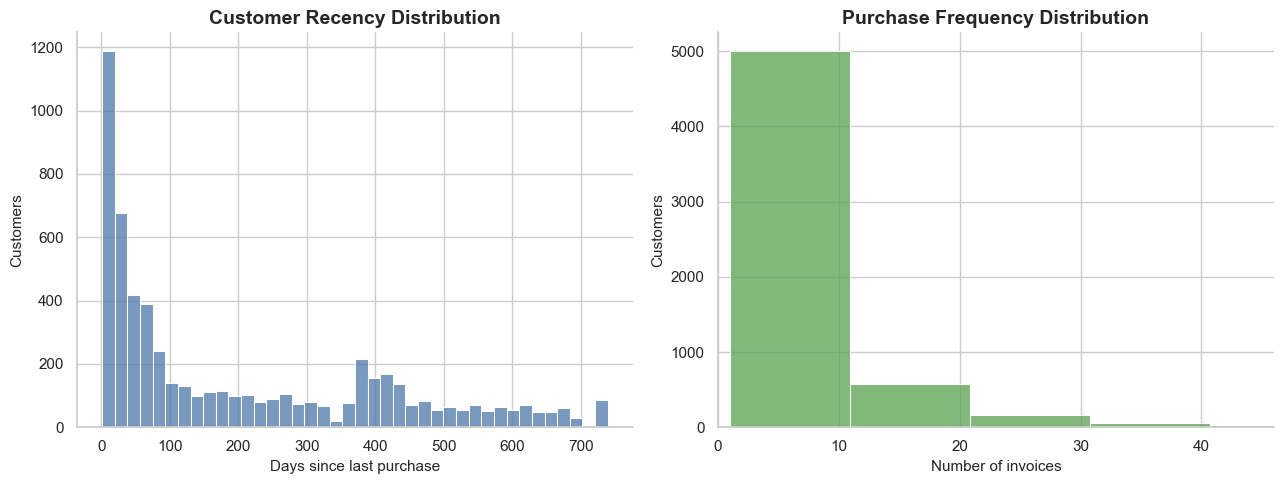

In [15]:
if HAS_PLOTS:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    sns.histplot(customer_features["recency"], bins=40, ax=axes[0], color="#4C78A8")
    axes[0].set_title("Customer Recency Distribution")
    axes[0].set_xlabel("Days since last purchase")
    axes[0].set_ylabel("Customers")

    sns.histplot(customer_features["frequency"], bins=40, ax=axes[1], color="#59A14F")
    axes[1].set_title("Purchase Frequency Distribution")
    axes[1].set_xlabel("Number of invoices")
    axes[1].set_ylabel("Customers")
    axes[1].set_xlim(0, customer_features["frequency"].quantile(0.99))

    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

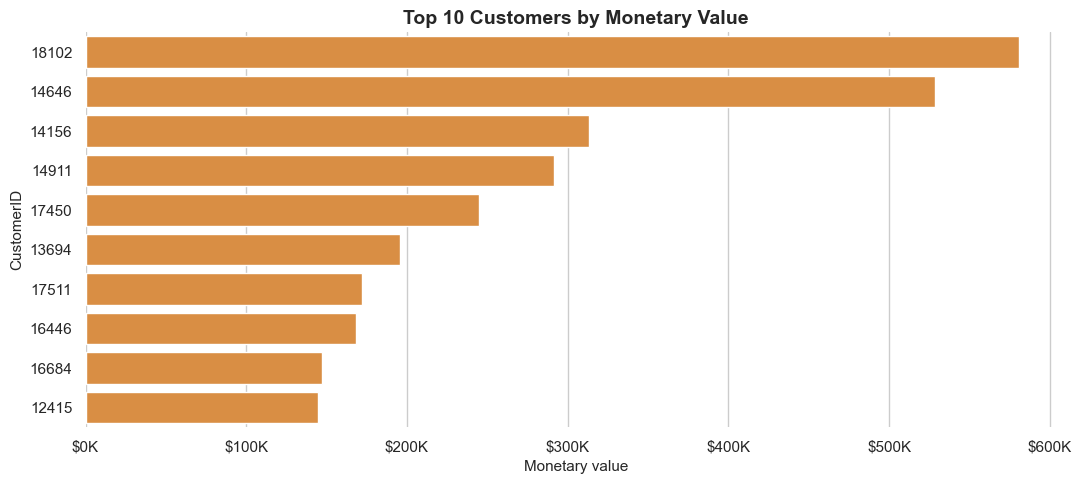

,CustomerID,frequency,monetary_value,recency,return_cancel_rate
5692,18102,145,"580,987.04",1,0.06
2277,14646,151,"528,602.52",2,0.08
1789,14156,156,"313,437.62",10,0.29
2538,14911,398,"291,420.81",1,0.28
5050,17450,51,"244,784.25",8,0.20
1331,13694,143,"195,640.69",4,0.15
5109,17511,60,"172,132.87",3,0.42
4061,16446,2,"168,472.50",1,1.00
4295,16684,55,"147,142.77",4,0.18
68,12415,28,"144,458.37",24,0.18


In [16]:
top_customers = customer_features.nlargest(10, "monetary_value").copy()

if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(
        data=top_customers,
        x="monetary_value",
        y=top_customers["CustomerID"].astype(str),
        ax=ax,
        color="#F28E2B",
    )
    ax.set_title("Top 10 Customers by Monetary Value")
    ax.set_xlabel("Monetary value")
    ax.set_ylabel("CustomerID")
    ax.xaxis.set_major_formatter(lambda value, _: f"${value/1_000:.0f}K")
    sns.despine(left=True, bottom=True)
    plt.tight_layout()
    plt.show()

top_customers_display = top_customers[
    ["CustomerID", "frequency", "monetary_value", "recency", "return_cancel_rate"]
].copy()
top_customers_display["monetary_value"] = top_customers_display["monetary_value"].round(2)
top_customers_display["return_cancel_rate"] = top_customers_display["return_cancel_rate"].round(4)
top_customers_display

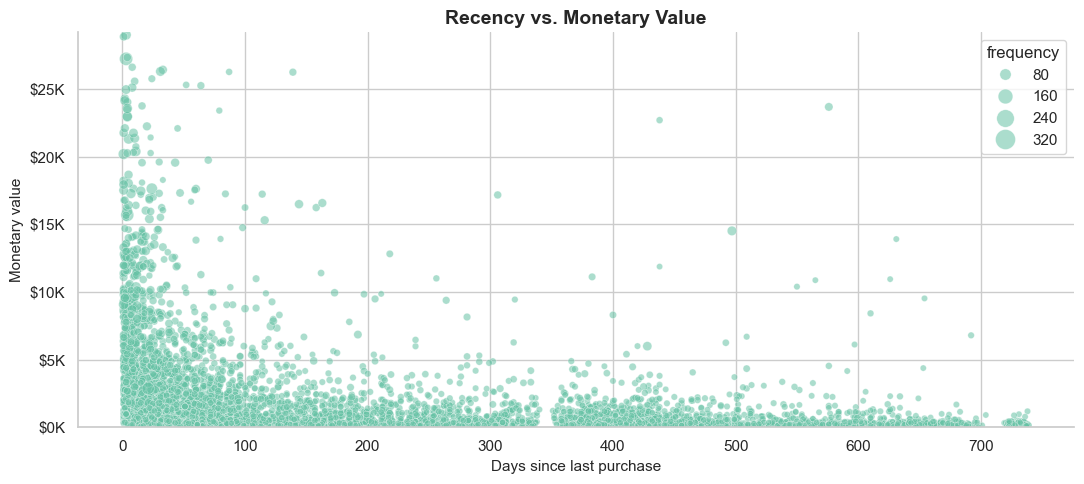

In [17]:
if HAS_PLOTS:
    fig, ax = plt.subplots(figsize=(11, 5))
    sns.scatterplot(
        data=customer_features,
        x="recency",
        y="monetary_value",
        size="frequency",
        sizes=(20, 250),
        alpha=0.55,
        ax=ax,
    )
    ax.set_title("Recency vs. Monetary Value")
    ax.set_xlabel("Days since last purchase")
    ax.set_ylabel("Monetary value")
    ax.set_ylim(0, customer_features["monetary_value"].quantile(0.99))
    ax.yaxis.set_major_formatter(lambda value, _: f"${value/1_000:.0f}K")
    sns.despine()
    plt.tight_layout()
    plt.show()
else:
    print("Skipping chart because plotting libraries are not available.")

## 11. Optional Export

The saved `customer_features.csv` file is protected by default. If you intentionally want to overwrite it
after reviewing the regenerated table and validation checks, change `SAVE_OUTPUTS` to `True` in the setup
cell and rerun this cell.

In [ ]:
if SAVE_OUTPUTS:
    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    customer_features.to_csv(CUSTOMER_FEATURES_PATH, index=False)
    print(f"Customer features were overwritten because SAVE_OUTPUTS=True: {CUSTOMER_FEATURES_PATH}")
else:
    print("SAVE_OUTPUTS=False, so customer_features.csv was not written or overwritten.")

## 12. Output Readiness

This notebook is complete when:

1. The feature quality checks show one row per customer.
2. The validation section matches the existing saved `customer_features.csv`.
3. The quick visual checks look reasonable.
4. `SAVE_OUTPUTS` remains `False` unless an intentional regeneration is needed.

Recommended next notebook: `03_churn_labeling_and_eda.ipynb`

Next tasks:

1. Define the inactivity/churn window.
2. Add the target label.
3. Explore active vs. inactive customer behavior.
4. Prepare the modeling dataset.